In [28]:
import os, time
import numpy as np
import torch
torch.set_num_threads(4)
 
from src.portfolio import default_portfolio
from src.ddpm import DDPM
from src.generators import make_grid
import src.experiments as ex
from src.importance_sampling import snis_estimate

from scipy.stats import norm


In [2]:
steps=4000
pool=600_000
R_main=200
R_scale=120
R_clt=4000
m_main=4000
PATH = "OUT"

In [7]:
t_all = time.time()
pf = default_portfolio(n=4, seed=0)
m_pnl, s_pnl = pf.pnl_mean, pf.pnl_std
print(f"portfolio P&L:  mean={m_pnl:.5f}  sd={s_pnl:.5f}")

grid = make_grid(m_pnl, s_pnl)
views = ex.build_views(m_pnl, s_pnl, grid)
print("\nviews and oracle budgets:")
for nm, (v, o, note) in views.items():
    print(f"  {nm:16s} rho={o.rho:.4f}  KL={o.kl:.4f}  ESSfrac=1/rho={1/o.rho:.3f}  | {note}")

print("\ntraining DDPM on the asset vector ...")
t0 = time.time()
ddpm = DDPM(n=pf.mu.shape[0], seed=0)
ddpm.train(lambda mm, rng: pf.sample_assets(mm, rng), steps=steps, verbose=True)
print(f"  train time {time.time()-t0:.0f}s")
print(f"sampling frozen diffusion pool of {pool} ...")
t0 = time.time()
chunk = 50_000
parts = []
for c0 in range(0, pool, chunk):
    cc = min(chunk, pool - c0)
    parts.append(ddpm.sample(cc, seed=12345 + c0))
    print(f"    sampled {c0+cc}/{pool}", flush=True)
Xpool = np.concatenate(parts, axis=0)
diff_pnl = pf.pnl(Xpool)
print(f"  sample time {time.time()-t0:.0f}s")

from src.metrics import ks_two_samples
from  src.generators import Oracle
base_oracle = Oracle("base", "forward", grid, u=np.ones_like(grid.z))
rng0 = np.random.default_rng(0)
raw_ks = ks_two_samples(diff_pnl[:50000], base_oracle)
print(f"  raw diffusion P&L KS vs true Gaussian (50k): {raw_ks:.5f}")

print(f"\nmain comparison  (m={m_main}, R={R_main}) ...")
t0 = time.time()
main_res = ex.run_main(views, m_main, R_main, m_pnl, s_pnl, diff_pnl, seed=0)
meta = dict(m=m_main, R=R_main, raw_diffusion_ks=raw_ks,
            pnl_mean=m_pnl, pnl_sd=s_pnl)
print(f"  done {time.time()-t0:.0f}s")

scale_names = ["var", "expectation", "rkl_moment_exp"]
m_grid = [250, 500, 1000, 2000, 4000, 8000]
print(f"\nscaling sweep on {scale_names}  (R={R_scale}) ...")
t0 = time.time()
scaling = ex.run_scaling(views, scale_names, m_grid, R_scale, m_pnl, s_pnl, diff_pnl, seed=1)
print(f"  done {time.time()-t0:.0f}s")

print(f"\nCLT variance check (Prop 10) on expectation view  (R={R_clt}) ...")
t0 = time.time()
ev, eo, _ = views["expectation"]
t_pts = list(np.linspace(m_pnl - 2 * s_pnl, m_pnl + 2 * s_pnl, 9))
clt_rows = ex.run_clt_check(ev, eo, m_pnl, s_pnl, m=4000, R=R_clt, t_points=t_pts, seed=2)
print(f"  done {time.time()-t0:.0f}s")

portfolio P&L:  mean=-0.00354  sd=0.07697

views and oracle budgets:
  bins             rho=1.1350  KL=0.0640  ESSfrac=1/rho=0.881  | 3 buckets at base q25/q75; natural (.25,.50,.25) -> (.40,.45,.15)
  var              rho=1.0526  KL=0.0207  ESSfrac=1/rho=0.950  | P(Z<=q05) raised 0.05 -> 0.10 (q fixed at base 5% quantile)
  var_cvar         rho=1.0269  KL=0.0082  ESSfrac=1/rho=0.974  | VaR95 fixed; CVaR95 raised 0.1552 -> 0.1738
  expectation      rho=1.2840  KL=0.1250  ESSfrac=1/rho=0.779  | mean shifted -0.0035 -> 0.0349 (+0.5 sd)
  rkl_moment       rho=1.0527  KL=0.0339  ESSfrac=1/rho=0.950  | E[Z^2] lowered 0.00594 -> 0.00416 (rational tilt)
  rkl_moment_exp   rho=1.0217  KL=0.0131  ESSfrac=1/rho=0.979  | mean fixed, E[Z^2] lowered 0.00594 -> 0.00475

training DDPM on the asset vector ...
  ddpm step     0  loss 1.00648
  ddpm step  1000  loss 0.50794
  ddpm step  2000  loss 0.50615
  ddpm step  3000  loss 0.50611
  ddpm step  3999  loss 0.50585
  train time 20s
sampling frozen di

In [15]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline

In [13]:
PRETTY = {
    "bins": "Bins (Prop 1)",
    "var": "VaR (Cor 1)",
    "var_cvar": "VaR+CVaR (Prop 3)",
    "expectation": "Expectation (exp tilt)",
    "rkl_moment": "Reverse-KL moment (P1)",
    "rkl_moment_exp": "Reverse-KL mom+exp (P2)",
}

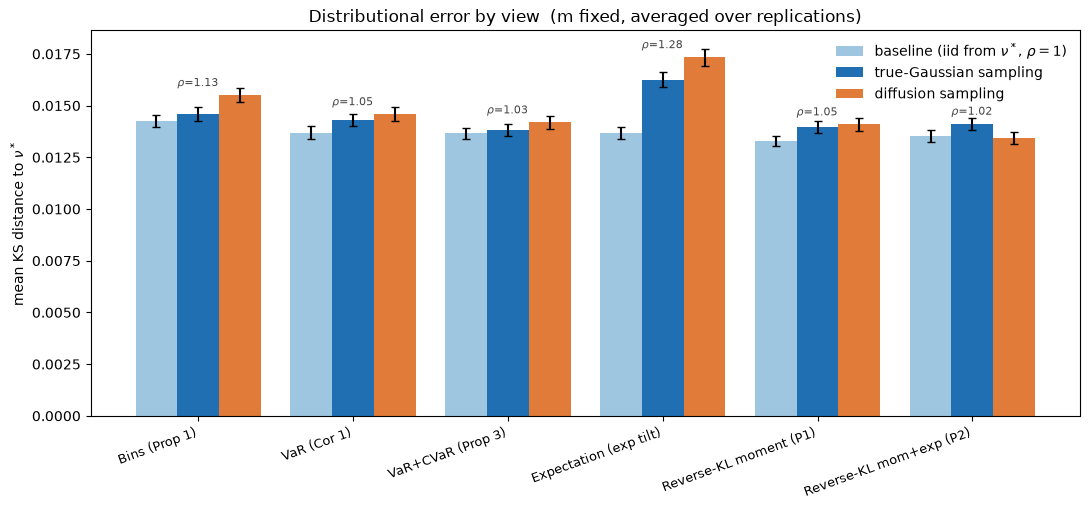

In [18]:
names = list(main_res.keys())
x = np.arange(len(names))
base = [main_res[n]["ks_base"] for n in names]
true = [main_res[n]["ks_true"] for n in names]
diff = [main_res[n]["ks_diff"] for n in names]
be = [main_res[n]["ks_base_se"] for n in names]
te = [main_res[n]["ks_true_se"] for n in names]
de = [main_res[n]["ks_diff_se"] for n in names]
w = 0.27
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.bar(x - w, base, w, yerr=be, capsize=3, label="baseline (iid from $\\nu^*$, $\\rho=1$)", color="#9ec6e0")
ax.bar(x, true, w, yerr=te, capsize=3, label="true-Gaussian sampling", color="#1f6fb2")
ax.bar(x + w, diff, w, yerr=de, capsize=3, label="diffusion sampling", color="#e07b39")
ax.set_xticks(x)
ax.set_xticklabels([PRETTY[n] for n in names], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("mean KS distance to $\\nu^*$")
ax.set_title(f"Distributional error by view  (m fixed, averaged over replications)")
ax.legend(frameon=False)
for xi, n in zip(x, names):
    ax.annotate(f"$\\rho$={main_res[n]['rho_oracle']:.2f}", (xi, max(true[list(names).index(n)], diff[list(names).index(n)])),
                textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8, color="#444")
fig.tight_layout()
fig.show()

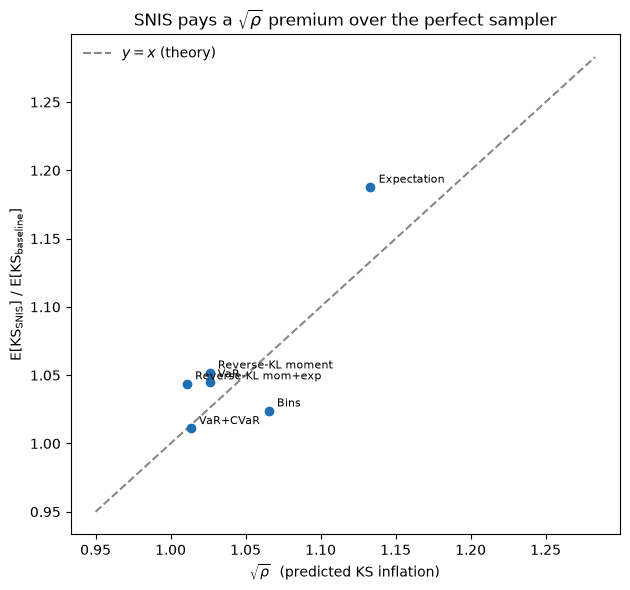

In [21]:
names = list(main_res.keys())
sr = np.array([main_res[n]["sqrt_rho"] for n in names])
ratio = np.array([main_res[n]["ratio_true_base"] for n in names])
fig, ax = plt.subplots(figsize=(6.4, 6.0))
lim = [0.95, max(sr.max(), ratio.max()) * 1.08]
ax.plot(lim, lim, "--", color="#888", label="$y=x$ (theory)")
ax.scatter(sr, ratio, c="#1f6fb2", zorder=3)
for n, a, b in zip(names, sr, ratio):
    ax.annotate(PRETTY[n].split(" (")[0], (a, b), textcoords="offset points",
                xytext=(6, 3), fontsize=8)
ax.set_xlabel("$\\sqrt{\\rho}$  (predicted KS inflation)")
ax.set_ylabel("E[KS$_{\\mathrm{SNIS}}$] / E[KS$_{\\mathrm{baseline}}$]")
ax.set_title("SNIS pays a $\\sqrt{\\rho}$ premium over the perfect sampler")
ax.legend(frameon=False); fig.tight_layout(); fig.show()

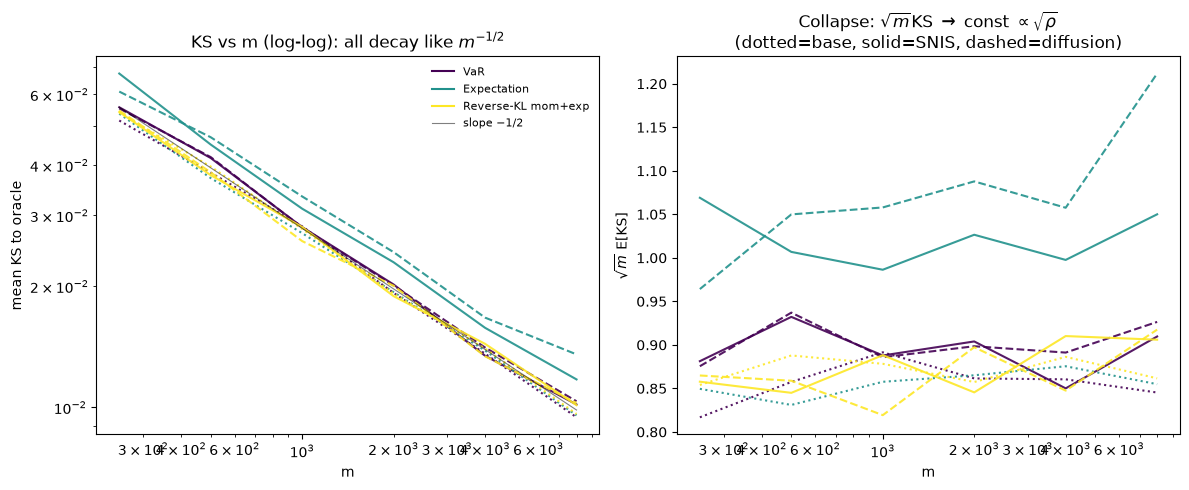

In [20]:
names = list(scaling.keys())
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cmap = plt.get_cmap("viridis")
for k, nm in enumerate(names):
    col = cmap(k / max(len(names) - 1, 1))
    m = np.array(scaling[nm]["m"], float)
    for key, ls, lab in [("base", ":", "base"), ("true", "-", "SNIS"), ("diff", "--", "diff")]:
        y = np.array(scaling[nm][key])
        axes[0].loglog(m, y, ls, color=col, alpha=0.9)
        axes[1].semilogx(m, np.sqrt(m) * y, ls, color=col, alpha=0.9)
    axes[0].plot([], [], "-", color=col, label=PRETTY[nm].split(" (")[0])

mref = np.array([scaling[names[0]]["m"][0], scaling[names[0]]["m"][-1]], float)
y0 = scaling[names[0]]["true"][0]
axes[0].loglog(mref, y0 * np.sqrt(mref[0] / mref), "-", color="k", lw=0.8, alpha=0.5,
                label="slope $-1/2$")
axes[0].set_xlabel("m"); axes[0].set_ylabel("mean KS to oracle")
axes[0].set_title("KS vs m (log-log): all decay like $m^{-1/2}$")
axes[0].legend(frameon=False, fontsize=8)
axes[1].set_xlabel("m"); axes[1].set_ylabel("$\\sqrt{m}\\;$E[KS]")
axes[1].set_title("Collapse: $\\sqrt{m}$KS $\\to$ const $\\propto\\sqrt{\\rho}$\n(dotted=base, solid=SNIS, dashed=diffusion)")
fig.tight_layout(); fig.show()

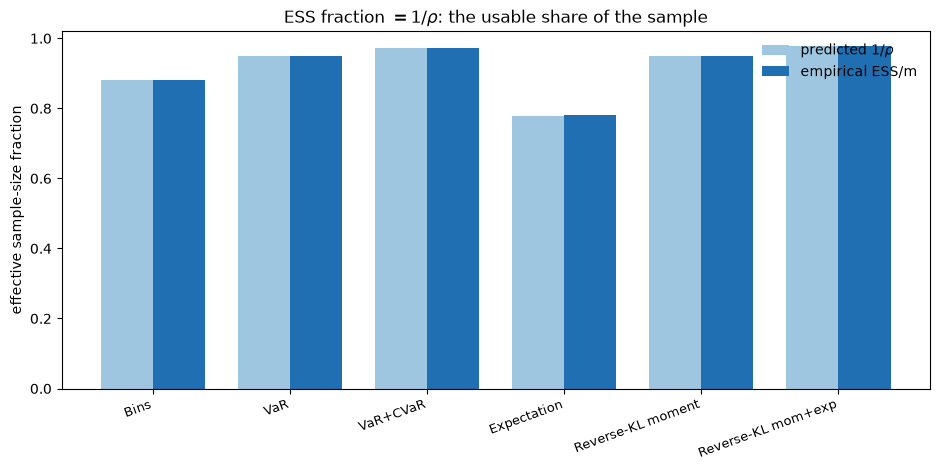

In [22]:
names = list(main_res.keys())
x = np.arange(len(names))
pred = [main_res[n]["ess_frac_pred"] for n in names]
emp = [main_res[n]["ess_frac"] for n in names]
w = 0.38
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.bar(x - w / 2, pred, w, label="predicted 1/$\\rho$", color="#9ec6e0")
ax.bar(x + w / 2, emp, w, label="empirical ESS/m", color="#1f6fb2")
ax.set_xticks(x); ax.set_xticklabels([PRETTY[n].split(" (")[0] for n in names], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("effective sample-size fraction"); ax.set_ylim(0, 1.02)
ax.set_title("ESS fraction $= 1/\\rho$: the usable share of the sample")
ax.legend(frameon=False); fig.tight_layout(); fig.show()

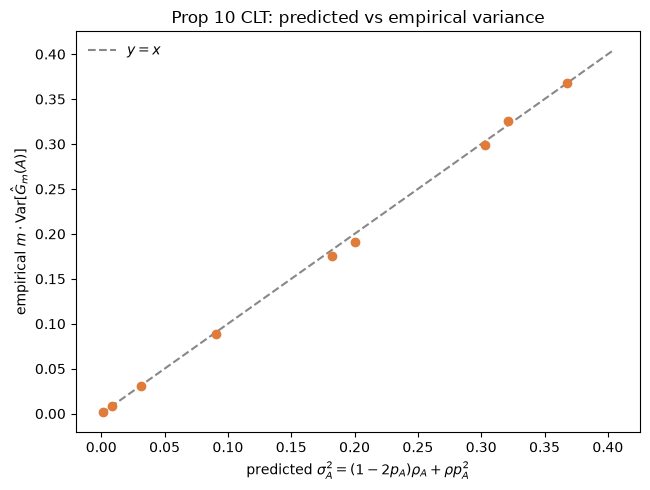

In [23]:
t = [r["t"] for r in clt_rows]
pred = [r["sigma2_pred"] for r in clt_rows]
emp = [r["sigma2_emp"] for r in clt_rows]
fig, ax = plt.subplots(figsize=(6.6, 5.0))
lim = [0, max(max(pred), max(emp)) * 1.1]
ax.plot(lim, lim, "--", color="#888", label="$y=x$")
ax.scatter(pred, emp, c="#e07b39", zorder=3)
ax.set_xlabel("predicted $\\sigma_A^2=(1-2p_A)\\rho_A+\\rho p_A^2$")
ax.set_ylabel("empirical $m\\cdot$Var$[\\hat G_m(A)]$")
ax.set_title("Prop 10 CLT: predicted vs empirical variance")
ax.legend(frameon=False); fig.tight_layout(); fig.show()

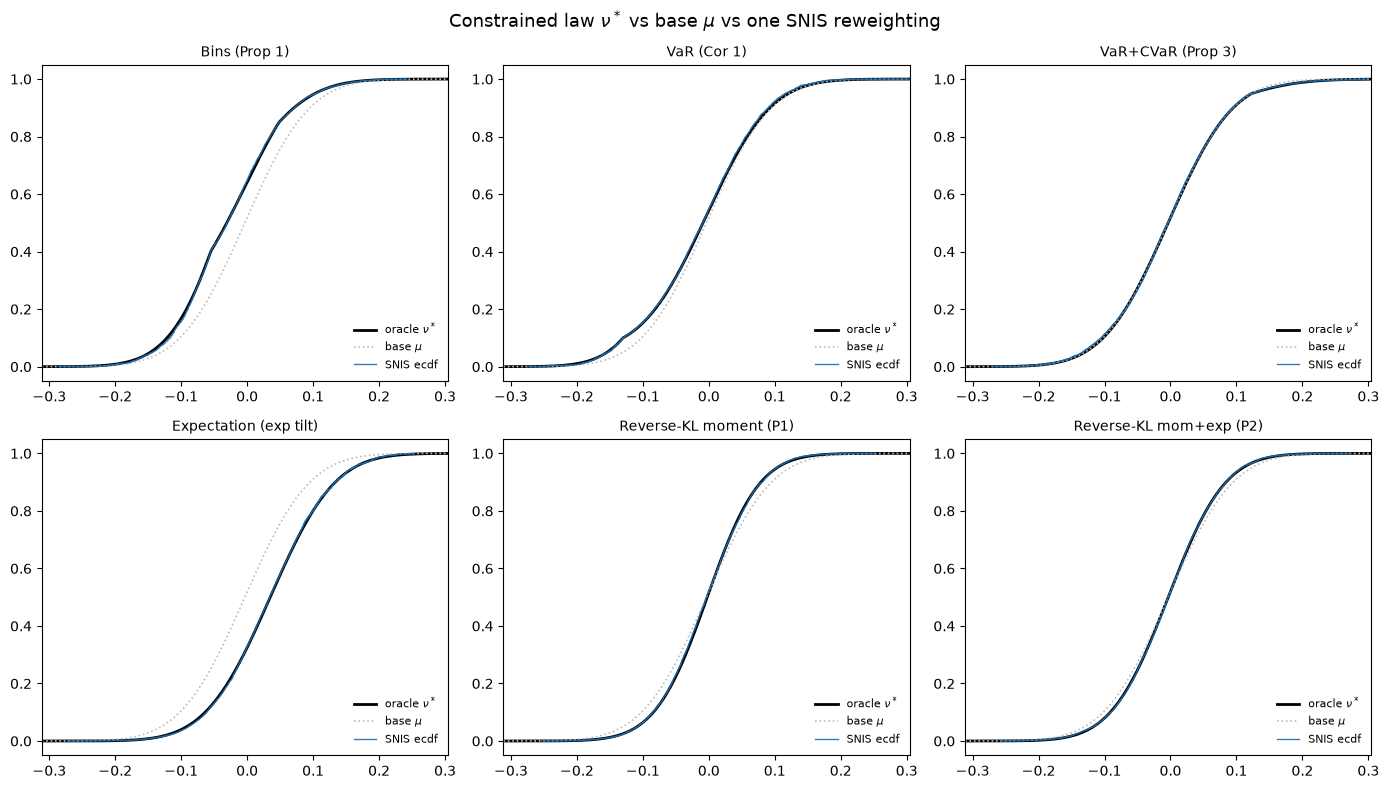

In [27]:
rng = np.random.default_rng(7)
names = list(views.keys())
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
m = 4000
for ax, nm in zip(axes.ravel(), names):
    view, oracle, _ = views[nm]
    zt = rng.normal(m_pnl, s_pnl, size=m)
    st = snis_estimate(view, zt)
    zz = oracle.grid.z
    ax.plot(zz, oracle.cdf, color="k", lw=2, label="oracle $\\nu^*$")
    # unweighted base law CDF for contrast
    ax.plot(zz, norm.cdf(zz, loc=m_pnl, scale=s_pnl),
            color="#bbbbbb", lw=1.2, ls=":", label="base $\\mu$")
    order = np.argsort(st.z); zc = st.z[order]; cw = np.cumsum(st.w[order])
    ax.step(zc, cw, where="post", color="#1f6fb2", lw=1.0, alpha=0.9, label="SNIS ecdf")
    ax.set_title(PRETTY[nm], fontsize=10)
    ax.set_xlim(m_pnl - 4 * s_pnl, m_pnl + 4 * s_pnl)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.suptitle("Constrained law $\\nu^*$ vs base $\\mu$ vs one SNIS reweighting", fontsize=13)
fig.tight_layout(); fig.show()

In [29]:
print("\n" + "=" * 110)
print(f"{'view':16s}{'rho':>8s}{'sqrtRho':>9s}{'ESSfrac':>9s}"
        f"{'KS_base':>10s}{'KS_true':>10s}{'KS_diff':>10s}{'tru/base':>9s}{'dif/tru':>8s}{'cerr':>9s}")
print("-" * 110)
for nm, d in main_res.items():
    if nm.startswith("_"):
        continue
    print(f"{nm:16s}{d['rho_oracle']:8.3f}{d['sqrt_rho']:9.3f}{d['ess_frac']:9.3f}"
            f"{d['ks_base']:10.5f}{d['ks_true']:10.5f}{d['ks_diff']:10.5f}"
            f"{d['ratio_true_base']:9.3f}{d['ratio_diff_true']:8.3f}{d['cerr_true']:9.1e}")
print("=" * 110)
print("\nCLT check (expectation view): predicted vs empirical sigma_A^2")
for r in clt_rows:
    print(f"  t={r['t']:+.4f}  pA={r['pA']:.3f}  pred={r['sigma2_pred']:.4f}  emp={r['sigma2_emp']:.4f}")


view                 rho  sqrtRho  ESSfrac   KS_base   KS_true   KS_diff tru/base dif/tru     cerr
--------------------------------------------------------------------------------------------------------------
bins               1.135    1.065    0.881   0.01425   0.01459   0.01551    1.024   1.063  1.3e-16
var                1.053    1.026    0.950   0.01369   0.01431   0.01458    1.045   1.019  2.8e-17
var_cvar           1.027    1.013    0.972   0.01365   0.01380   0.01418    1.011   1.028  5.3e-16
expectation        1.284    1.133    0.780   0.01369   0.01626   0.01734    1.188   1.067  9.5e-16
rkl_moment         1.053    1.026    0.950   0.01328   0.01397   0.01409    1.052   1.008  2.6e-17
rkl_moment_exp     1.022    1.011    0.979   0.01353   0.01412   0.01344    1.044   0.952  5.6e-19

CLT check (expectation view): predicted vs empirical sigma_A^2
  t=-0.1575  pA=0.006  pred=0.0018  emp=0.0017
  t=-0.1190  pA=0.023  pred=0.0083  emp=0.0080
  t=-0.0805  pA=0.067  pred=0.0310  e